## Hyporheic Averaging Based on Turbidity Threshold

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import linregress
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# import the data, and make first column the index 
sp_sample_SSC = pd.read_csv('../../data/SSC/original_SSC/samples_spring_SSC.csv', index_col=1, parse_dates=True)
sm_sample_SSC = pd.read_csv('../../data/SSC/original_SSC/samples_summer_SSC_up.csv', index_col=1, parse_dates=True)
sp_turb = pd.read_csv('../../data/SSC/turb_SP23_clean_complete.csv', index_col=0, parse_dates=True)
sm_turb = pd.read_csv('../../data/SSC/turb_SM23_clean_complete.csv', index_col=0, parse_dates=True)
q = pd.read_csv('../../data/discharge/discharge_2023.csv', index_col=0, parse_dates=True)
VHF_spring = pd.read_csv('../../data/hyporheic_fluxes/spring_HF.csv', index_col=0, parse_dates=True)
VHF_summer = pd.read_csv('../../data/hyporheic_fluxes/summer_HF.csv', index_col=0, parse_dates=True)

# smooth the q data with a rolling mean of 10 measurements (for plotting purposes)
q = q.rolling(window=10, min_periods=1).mean()
# separate the spring and summer data
q_sp = q.loc['2023-03-21':'2023-06-20']
q_sm = q.loc['2023-06-20':'2023-09-19']
VHF_spring = VHF_spring.loc['2023-03-21':'2023-06-20']
VHF_summer = VHF_summer.loc['2023-06-20':'2023-09-19']

# drop nan values 
sp_sample_SSC = sp_sample_SSC.dropna()
sm_sample_SSC = sm_sample_SSC.dropna()
sp_turb = sp_turb.dropna()
sm_turb = sm_turb.dropna()
# deleting duplicates, in case there are any
sm_turb = sm_turb[~sm_turb.index.duplicated(keep='first')]
sp_turb = sp_turb[~sp_turb.index.duplicated(keep='first')]
sm_turb = sm_turb.sort_index()
sp_turb = sp_turb.sort_index()
# resample the data to 1 minute intervals and interpolate
sp_turb = sp_turb.resample('1min').interpolate()
sm_turb = sm_turb.resample('1min').interpolate()
# merge turbidity onto sample data on the dates
sp_sample_SSC = sp_sample_SSC.merge(sp_turb, on='Date_Time', how='left')
sm_sample_SSC = sm_sample_SSC.merge(sm_turb, on='Date_Time', how='left')
# delete samples with SSC values <0 mg/L 
sp_sample_SSC_gsd = sp_sample_SSC[sp_sample_SSC['SSC (uL/L)'] > 0]
sm_sample_SSC_gsd = sm_sample_SSC[sm_sample_SSC['SSC (uL/L)'] > 0]
# keep others in another df
sp_sample_SSC_neg = sp_sample_SSC[sp_sample_SSC['SSC (uL/L)'] == 0]
sm_sample_SSC_neg = sm_sample_SSC[sm_sample_SSC['SSC (uL/L)'] == 0]

#### Scatter Plots

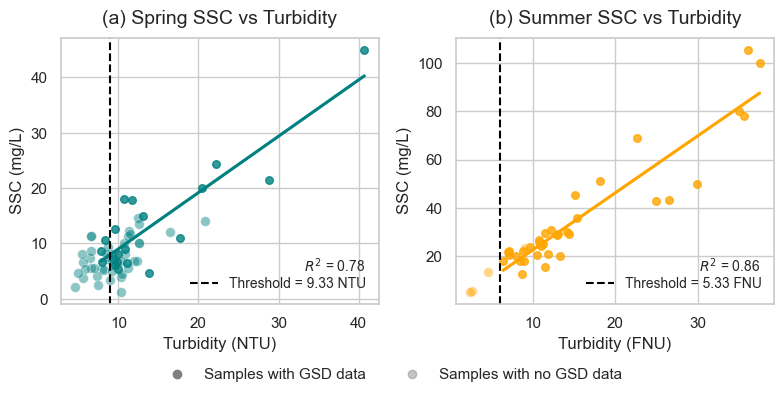

In [2]:
# combined scatter plot for both seasons as subplots
sns.set(style="whitegrid") 
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
# spring subplot
x_sp = sp_sample_SSC_gsd['TurbClean']
y_sp = sp_sample_SSC_gsd['SSC (mg/L)']
slope_sp, intercept_sp, r_value_sp, p_value_sp, std_err_sp = linregress(x_sp, y_sp)
sns.scatterplot(data=sp_sample_SSC_neg, x='TurbClean', y='SSC (mg/L)', color='teal', ax=axes[0], alpha=0.45, s=50, label='Samples with no GSD data')
sns.regplot(data=sp_sample_SSC_gsd, x='TurbClean', y='SSC (mg/L)', color='teal', ax=axes[0], ci=None, scatter_kws={'s': 30}, label='Samples with GSD data')


eq_text_sp = f"$R^2$ = {r_value_sp**2:.2f}"
axes[0].text(0.765, 0.18, eq_text_sp, transform=axes[0].transAxes, fontsize=10, verticalalignment='top')
axes[0].axvline(9, color='black', linestyle='--', linewidth=1.5, label='Threshold = 9.33 NTU')
axes[0].set_title('(a) Spring SSC vs Turbidity', fontsize=14, pad=10)
axes[0].set_xlabel('Turbidity (NTU)', fontsize=12)
axes[0].set_ylabel('SSC (mg/L)', fontsize=12)

# summer subplot
x_sm = sm_sample_SSC_gsd['TurbClean']
y_sm = sm_sample_SSC_gsd['SSC (mg/L)']
slope_sm, intercept_sm, r_value_sm, p_value_sm, std_err_sm = linregress(x_sm, y_sm)
sns.scatterplot(data=sm_sample_SSC_neg, x='TurbClean', y='SSC (mg/L)', color='orange', ax=axes[1], alpha=0.45, s=50, label='Samples with no GSD data')
sns.regplot(data=sm_sample_SSC_gsd, x='TurbClean', y='SSC (mg/L)', color='orange', ax=axes[1], ci=None, scatter_kws={'s': 30}, label='Samples with GSD data')

eq_text_sm = f"$R^2$ = {r_value_sm**2:.2f}"
axes[1].text(0.765, 0.18, eq_text_sm, transform=axes[1].transAxes, fontsize=10, verticalalignment='top')
axes[1].axvline(6, color='black', linestyle='--', linewidth=1.5, label='Threshold = 5.33 FNU')
axes[1].set_title('(b) Summer SSC vs Turbidity', fontsize=14, pad=10)
axes[1].set_xlabel('Turbidity (FNU)', fontsize=12)
axes[1].set_ylabel('SSC (mg/L)', fontsize=12)

# legends and descriptors:
thresh_sp = Line2D([0], [0], color='black', linestyle='--', linewidth=1.5, label='Threshold = 9.33 NTU')
thresh_sm = Line2D([0], [0], color='black', linestyle='--', linewidth=1.5, label='Threshold = 5.33 FNU')
axes[0].legend(handles=[thresh_sp], loc='lower right', frameon=False, fontsize=10)
axes[1].legend(handles=[thresh_sm], loc='lower right', frameon=False, fontsize=10)
# gray data points shared bottom legend
legend_reg = Line2D([0], [0], marker='o', linestyle='None', color='gray', markerfacecolor='gray', markeredgecolor='gray',
                    label='Samples with GSD data')
legend_no = Line2D([0], [0], marker='o', linestyle='None', color='gray', markerfacecolor='gray', markeredgecolor='gray', alpha=0.45,
                    label='Samples with no GSD data')

fig.legend(handles=[legend_reg, legend_no], loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.01))
plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.savefig('SSC_vs_Turbidity_Relationship.jpg', dpi=500)
plt.show()


In [3]:
# input the turbidity threshold
spring_threshold = 9.5
summer_threshold = 5.8

# find spring exceedance regions
spring_exceeds = sp_turb['TurbClean'] > spring_threshold
spring_regions = []
in_event = False
for i in range(len(spring_exceeds)):
    if spring_exceeds.iloc[i] and not in_event:
        start = sp_turb.index[i]
        in_event = True
    elif not spring_exceeds.iloc[i] and in_event:
        end = sp_turb.index[i]
        spring_regions.append((start, end))
        in_event = False
if in_event:
    spring_regions.append((start, sp_turb.index[-1]))

# find summer exceedance regions
summer_exceeds = sm_turb['TurbClean'] > summer_threshold
summer_regions = []
in_event = False
for i in range(len(summer_exceeds)):
    if summer_exceeds.iloc[i] and not in_event:
        start = sm_turb.index[i]
        in_event = True
    elif not summer_exceeds.iloc[i] and in_event:
        end = sm_turb.index[i]
        summer_regions.append((start, end))
        in_event = False
if in_event:
    summer_regions.append((start, sm_turb.index[-1]))

# spring: discharge values at SSC sample times
spring_discharge_at_samples = q_sp.reindex(sp_sample_SSC.index, method='nearest')
# summer: discharge values at SSC sample times
summer_discharge_at_samples = q_sm.reindex(sm_sample_SSC.index, method='nearest')

#### Time Series (V1)

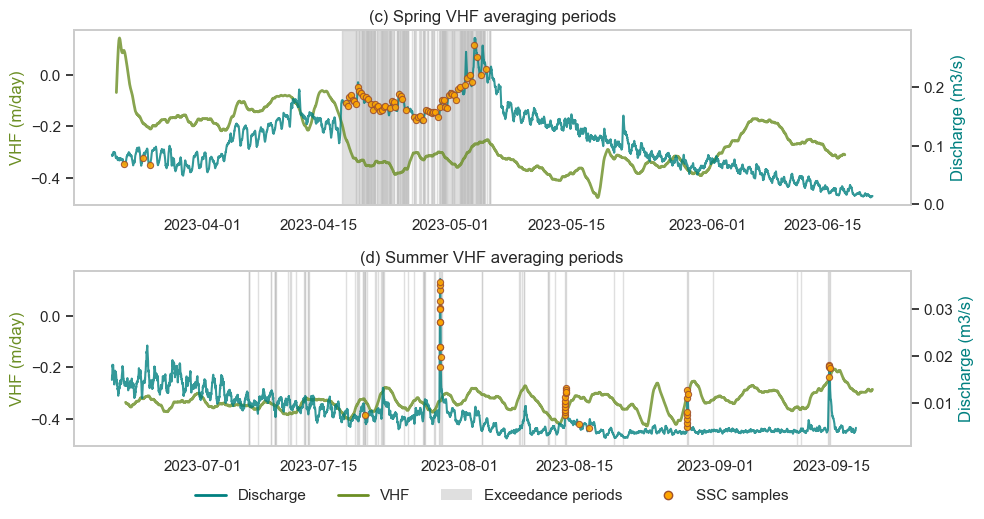

In [4]:
fig, ax1 = plt.subplots(2, 1, figsize=(10, 5))

# common VHF y-limits across both seasons
vhf_spring = VHF_spring['T2'] * 86400
vhf_summer = VHF_summer['T2'] * 86400
vhf_min = min(vhf_spring.min(), vhf_summer.min())
vhf_max = max(vhf_spring.max(), vhf_summer.max())
pad = 0.05 * (vhf_max - vhf_min)

### SPRING ###
# VHF
ax1[0].plot(VHF_spring.index, vhf_spring, color='olivedrab', label='VHF (m/day)', linewidth=2, alpha=0.8)
# discharge and Samples
ax2 = ax1[0].twinx()
ax2.plot(q_sp.index, q_sp['Q'], label='Discharge (m3/s)', alpha=0.8, color='teal')
ax2.scatter(sp_sample_SSC.index, spring_discharge_at_samples['Q'], c='orange', marker='o',
            s=20, alpha=0.9, label='SSC samples', zorder=5, edgecolor='sienna', linewidth=0.8)
# averaging periods highlighted
for start, end in spring_regions:
    ax1[0].axvspan(start, end, color='silver', alpha=0.5)

ax1[0].set_ylabel('VHF (m/day)', color='olivedrab')
ax1[0].set_ylim(vhf_min - pad, vhf_max + pad)
ax2.set_ylabel('Discharge (m3/s)', color='teal')
ax1[0].set_title('(c) Spring VHF averaging periods')
ax1[0].grid(False)
ax2.grid(False)

### SUMMER ###
# VHF 
ax1[1].plot(VHF_summer.index, vhf_summer, color='olivedrab', label='VHF (m/day)', linewidth=2, alpha=0.8)
# discharge and Samples
ax2 = ax1[1].twinx()
ax2.plot(q_sm.index, q_sm['Q'], label='Discharge (m3/s)', alpha=0.8, color='teal')
ax2.scatter(sm_sample_SSC.index, summer_discharge_at_samples['Q'], c='orange', marker='o',
            s=20, alpha=0.9, label='SSC samples', zorder=5, edgecolor='sienna', linewidth=0.8)
# averaging periods highlighted
for start, end in summer_regions:
    ax1[1].axvspan(start, end, color='silver', alpha=0.5)
ax1[1].set_ylabel('VHF (m/day)', color='olivedrab')
ax1[1].set_ylim(vhf_min - pad, vhf_max + pad)
ax2.set_ylabel('Discharge (m3/s)', color='teal')
ax1[1].set_title('(d) Summer VHF averaging periods')
ax1[1].grid(False)
ax2.grid(False)

# legend handles for the shared legend
legend_vhf = Line2D([0], [0], color='olivedrab', lw=2, label='VHF')
legend_q = Line2D([0], [0], color='teal', lw=2, label='Discharge')
legend_exceed = Patch(facecolor='silver', edgecolor='none', alpha=0.5,
                        label='Exceedance periods')
legend_ssc = Line2D([0], [0], marker='o', linestyle='None',
                    markerfacecolor='orange', markeredgecolor='sienna',
                    markersize=6, label='SSC samples')
# plot legend
fig.legend(handles=[legend_q, legend_vhf, legend_exceed, legend_ssc], loc='lower center',
    ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

plt.tight_layout()
plt.savefig('Turbidity_Threshold_Exceedance_V1.jpg', dpi=500)
plt.show()

#### Time Series (V2)

In [5]:
# separate the spring and summer data
q_sp = q.loc['2023-04-08':'2023-05-15']
q_sm = q.loc['2023-07-01':'2023-09-19']
VHF_spring = VHF_spring.loc['2023-04-08':'2023-05-15']
VHF_summer = VHF_summer.loc['2023-07-01':'2023-09-19']
sp_sample_SSC = sp_sample_SSC.merge(sp_turb, on='Date_Time')
sm_sample_SSC = sm_sample_SSC.merge(sm_turb, on='Date_Time')
# spring: discharge values at SSC sample times
spring_discharge_at_samples = q_sp.reindex(sp_sample_SSC.index, method='nearest')
# summer: discharge values at SSC sample times
summer_discharge_at_samples = q_sm.reindex(sm_sample_SSC.index, method='nearest')


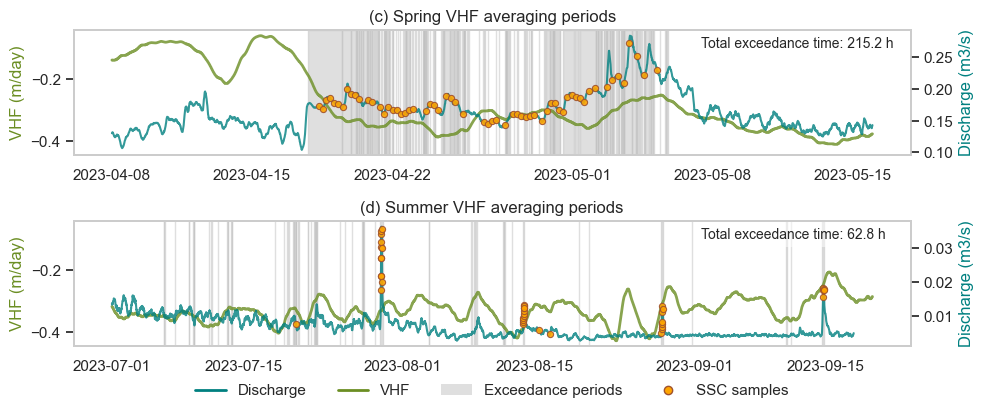

In [8]:
fig, ax1 = plt.subplots(2, 1, figsize=(10, 4))

# common VHF y-limits across both seasons
vhf_spring = VHF_spring['T2'] * 86400
vhf_summer = VHF_summer['T2'] * 86400
vhf_min = min(vhf_spring.min(), vhf_summer.min())
vhf_max = max(vhf_spring.max(), vhf_summer.max())
pad = 0.05 * (vhf_max - vhf_min)

### SPRING ###
# VHF
ax1[0].plot(VHF_spring.index, vhf_spring, color='olivedrab', label='VHF (m/day)', linewidth=2, alpha=0.8)
# discharge and Samples
ax2 = ax1[0].twinx()
ax2.plot(q_sp.index, q_sp['Q'], label='Discharge (m3/s)', alpha=0.8, color='teal')
ax2.scatter(sp_sample_SSC.index, spring_discharge_at_samples['Q'], c='orange', marker='o',
            s=20, alpha=0.9, label='SSC samples', zorder=5, edgecolor='sienna', linewidth=0.8)
# averaging periods highlighted
for start, end in spring_regions:
    ax1[0].axvspan(start, end, color='silver', alpha=0.5)

ax1[0].set_ylabel('VHF (m/day)', color='olivedrab')
ax1[0].set_ylim(vhf_min - pad, vhf_max + pad)
ax2.set_ylabel('Discharge (m3/s)', color='teal')
ax1[0].set_title('(c) Spring VHF averaging periods')
ax1[0].grid(False)
ax2.grid(False)

### SUMMER ###
# VHF 
ax1[1].plot(VHF_summer.index, vhf_summer, color='olivedrab', label='VHF (m/day)', linewidth=2, alpha=0.8)
# discharge and Samples
ax2 = ax1[1].twinx()
ax2.plot(q_sm.index, q_sm['Q'], label='Discharge (m3/s)', alpha=0.8, color='teal')
ax2.scatter(sm_sample_SSC.index, summer_discharge_at_samples['Q'], c='orange', marker='o',
            s=20, alpha=0.9, label='SSC samples', zorder=5, edgecolor='sienna', linewidth=0.8)
# averaging periods highlighted
for start, end in summer_regions:
    ax1[1].axvspan(start, end, color='silver', alpha=0.5)
ax1[1].set_ylabel('VHF (m/day)', color='olivedrab')
ax1[1].set_ylim(vhf_min - pad, vhf_max + pad)
ax2.set_ylabel('Discharge (m3/s)', color='teal')
ax1[1].set_title('(d) Summer VHF averaging periods')
ax1[1].grid(False)
ax2.grid(False)

# legend handles for the shared legend
legend_vhf = Line2D([0], [0], color='olivedrab', lw=2, label='VHF')
legend_q = Line2D([0], [0], color='teal', lw=2, label='Discharge')
legend_exceed = Patch(facecolor='silver', edgecolor='none', alpha=0.5,
                        label='Exceedance periods')
legend_ssc = Line2D([0], [0], marker='o', linestyle='None',
                    markerfacecolor='orange', markeredgecolor='sienna',
                    markersize=6, label='SSC samples')
# plot legend
fig.legend(handles=[legend_q, legend_vhf, legend_exceed, legend_ssc], loc='lower center',
    ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

# adding time in suspension text
ax1[0].text(0.75, 0.95, f"Total exceedance time: 215.2 h", transform=ax1[0].transAxes,
    va="top", ha="left", fontsize=10, bbox=dict(facecolor="white", alpha=0.5, edgecolor="none"))
ax1[1].text(0.75, 0.95, f"Total exceedance time: 62.8 h", transform=ax1[1].transAxes, 
    va="top", ha="left", fontsize=10, bbox=dict(facecolor="white", alpha=0.5, edgecolor="none"))

plt.tight_layout()
plt.savefig('Turbidity_Threshold_Exceedance_V2.jpg', dpi=900, bbox_inches='tight')
plt.show()